# Feature Selection and Model Training Report

## Steps Overview
- **Load and Prepare Data**: Load dataset, remove unnecessary columns
- **Split Data**: Split into train and test sets
- **Feature Selection with Variance Threshold**: Remove low-variance features
- **Bayesian Optimization for Hyperparameter Tuning**: Tune XGBoost parameters
- **Train XGBoost with Best Parameters**: Train model on selected features
- **Evaluate Model Performance**: Compute accuracy and classification report
- **Model-Based Feature Selection**: Select important features using trained model
- **Compare Model Performance**: Compare accuracy before and after feature selection
- **Learning Curve Analysis**: Assess generalization performance
- **Compare Performance Across Models**: Train and evaluate Logistic Regression, Random Forest, KNN, SVM

---

## Step 1: Load and Prepare Data

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from skopt import BayesSearchCV
from skopt.space import Real, Integer
from sklearn.feature_selection import VarianceThreshold, SelectFromModel
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

randomState = 42

final_clean_data = pd.read_pickle('final_cleaned_glioma_data.pkl')
print("Loaded Data Shape:", final_clean_data.shape)

df_clean = final_clean_data.drop(columns=['Unnamed: 0', 'age_at_initial_pathologic_diagnosis', 
                                          'gender', 'initial_pathologic_dx_year', 'birth_days_to'])

Loaded Data Shape: (578, 403960)


## Step 2: Split Data into Train and Test

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    df_clean.iloc[:, :-1],  # Features
    df_clean["classification.2021_simplified.labels"],  # Target
    test_size=0.2, 
    random_state=randomState, 
    stratify=df_clean["classification.2021_simplified.labels"]
)

## Step 3: Feature Selection with Variance Threshold

In [21]:
threshold = 0.01  
selector = VarianceThreshold(threshold=threshold)
selector.fit(X_train)  


selected_features = X_train.columns[selector.get_support()]

X_train_reduced = X_train[selected_features]
X_test_reduced = X_test[selected_features]

print(f"Original shape: {X_train.shape} → Reduced shape: {X_train_reduced.shape}")

Original shape: (462, 403954) → Reduced shape: (462, 162761)


## Step 4: Bayesian Optimization for XGBoost

In [ ]:

X_train_reduced = X_train_reduced.astype(np.float32)
X_test_reduced = X_test_reduced.astype(np.float32)

search_spaces = {
    'reg_alpha': Real(10, 100, prior='log-uniform'),
    'reg_lambda': Real(10, 100, prior='log-uniform'),
    'max_depth': Integer(3, 5),
    'learning_rate': Real(0.001, 0.05, prior='log-uniform'),
    'n_estimators': Integer(50, 100),
    'colsample_bytree': Real(0.1, 0.3),
    'subsample': Real(0.5, 0.8)
}

xgb_clf = xgb.XGBClassifier(
    objective="multi:softmax",
    num_class=len(y_train.unique()),
    eval_metric="mlogloss",
    tree_method="hist",  
    n_jobs=-1
)

bayes_search = BayesSearchCV(
    xgb_clf,
    search_spaces,
    n_iter=20,
    scoring='accuracy',
    cv=3,
    n_jobs=-1,
    verbose=3
)

bayes_search.fit(X_train_reduced, y_train)

print("\n✅ Best Parameters Found:", bayes_search.best_params_)



✅ Best Parameters Found: OrderedDict([('colsample_bytree', 0.25276592895441286), ('learning_rate', 0.001037772866579333), ('max_depth', 5), ('n_estimators', 86), ('reg_alpha', 11.553140668247567), ('reg_lambda', 14.308787386296595), ('subsample', 0.6914397498447116)])

## Step 5: Train XGBoost with Best Parameters

In [31]:
best_params = {
    "colsample_bytree": 0.25276592895441286,
    "learning_rate": 0.001037772866579333,
    "max_depth": 5,
    "n_estimators": 86,
    "reg_alpha": 11.553140668247567,
    "reg_lambda": 14.308787386296595,
    "subsample": 0.6914397498447116,
    "objective": "multi:softmax",
    "num_class": len(y_train.unique()),  
    "eval_metric": "mlogloss",
    "tree_method": "hist",  
    "n_jobs": -1
}

best_xgb = xgb.XGBClassifier(**best_params)
best_xgb.fit(X_train_reduced, y_train)

y_pred = best_xgb.predict(X_test_reduced)
accuracy = accuracy_score(y_test, y_pred)

print(f"\n✅ Test Accuracy: {accuracy:.4f}")
print("\n🔹 Classification Report:\n", classification_report(y_test, y_pred))


✅ Test Accuracy: 0.9828

🔹 Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.96      0.98        48
           1       0.97      1.00      0.99        36
           2       0.97      1.00      0.98        32

    accuracy                           0.98       116
   macro avg       0.98      0.99      0.98       116
weighted avg       0.98      0.98      0.98       116



# Step 6: Extract and Plot Feature Importances

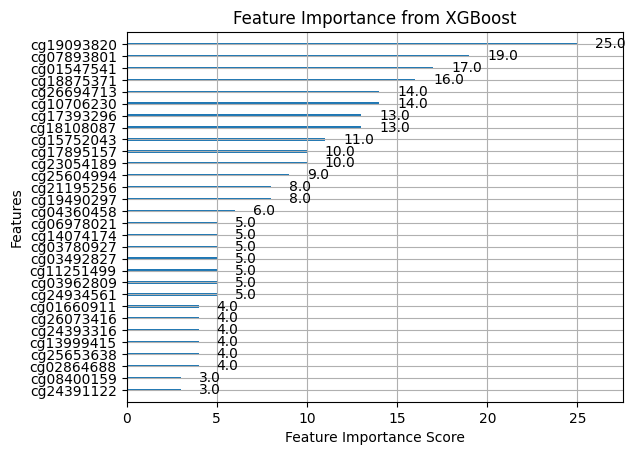

In [38]:
xgb.plot_importance(best_xgb, max_num_features=30, importance_type='weight', xlabel="Feature Importance Score", title="Feature Importance from XGBoost")
plt.show()

# Step 7: Model Based Feature Selection

In [28]:

selector_model = SelectFromModel(best_xgb, threshold="mean")  
selector_model.fit(X_train_reduced, y_train)  


selected_features = X_train_reduced.columns[selector_model.get_support()]


X_train_selected = pd.DataFrame(selector_model.transform(X_train_reduced), 
                                columns=selected_features, index=X_train_reduced.index)

X_test_selected = pd.DataFrame(selector_model.transform(X_test_reduced), 
                               columns=selected_features, index=X_test_reduced.index)

print(f"\n📌 Feature selection using XGBoost importance:")
print(f"Original shape: {X_train_reduced.shape} → Selected shape: {X_train_selected.shape}")


best_params = {
    'colsample_bytree': 0.25276592895441286,
    'learning_rate': 0.001037772866579333,
    'max_depth': 5,
    'n_estimators': 86,
    'reg_alpha': 11.553140668247567,
    'reg_lambda': 14.308787386296595,
    'subsample': 0.6914397498447116,
    'objective': "multi:softmax",
    'num_class': len(y_train.unique()),
    'eval_metric': "mlogloss",
    'tree_method': "hist",  
    'n_jobs': -1
}

best_xgb_selected = xgb.XGBClassifier(**best_params)
best_xgb_selected.fit(X_train_selected, y_train)

y_pred_selected = best_xgb_selected.predict(X_test_selected)
accuracy_selected = accuracy_score(y_test, y_pred_selected)

# Compare performance before and after feature selection
print(f"\n✅ Original Test Accuracy: {accuracy:.4f}") 
print(f"✅ Test Accuracy after feature selection: {accuracy_selected:.4f}")
print("\n🔹 Classification Report After Feature Selection:\n", classification_report(y_test, y_pred_selected))


📌 Feature selection using XGBoost importance:
Original shape: (462, 162761) → Selected shape: (462, 465)

✅ Original Test Accuracy: 0.9828
✅ Test Accuracy after feature selection: 0.9741

🔹 Classification Report After Feature Selection:
               precision    recall  f1-score   support

           0       1.00      0.94      0.97        48
           1       0.95      1.00      0.97        36
           2       0.97      1.00      0.98        32

    accuracy                           0.97       116
   macro avg       0.97      0.98      0.98       116
weighted avg       0.98      0.97      0.97       116



## Step 8: Accuracy as the Number of Features Increase



Top-10 Features → CV Accuracy: 0.7575
Top-20 Features → CV Accuracy: 0.7618
Top-30 Features → CV Accuracy: 0.7662
Top-40 Features → CV Accuracy: 0.9263
Top-50 Features → CV Accuracy: 0.9783
Top-60 Features → CV Accuracy: 0.9870
Top-70 Features → CV Accuracy: 0.9913
Top-80 Features → CV Accuracy: 0.9892
Top-90 Features → CV Accuracy: 0.9913
Top-100 Features → CV Accuracy: 0.9892


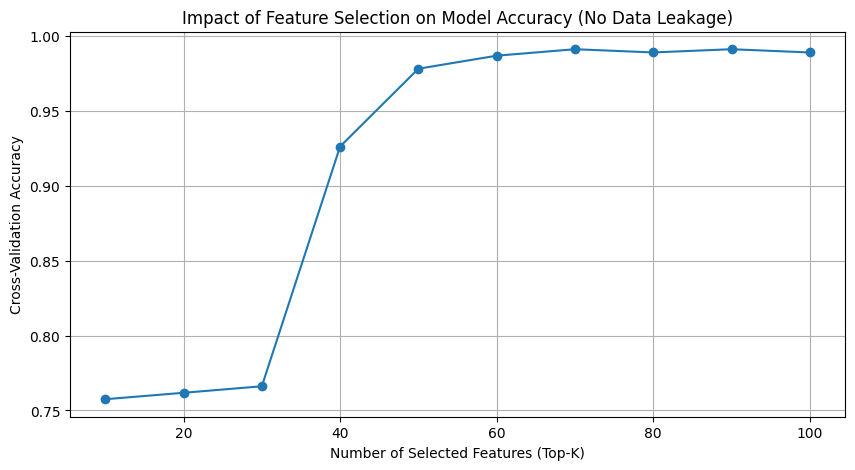

In [ ]:
from sklearn.model_selection import cross_val_score

feature_importances = best_xgb.feature_importances_
sorted_indices = np.argsort(feature_importances)[::-1]  
sorted_features = X_train_reduced.columns[sorted_indices]

from sklearn.model_selection import StratifiedKFold

feature_counts = np.arange(10, min(len(sorted_features), 101), 10)  
accuracy_scores = []

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=randomState) 

for k in feature_counts:
    selected_features = sorted_features[:k]  

    X_train_selected = X_train_reduced[selected_features]

    xgb_model = xgb.XGBClassifier(**best_params)
    scores = cross_val_score(xgb_model, X_train_selected, y_train, cv=cv, scoring='accuracy')

    mean_accuracy = np.mean(scores)
    accuracy_scores.append(mean_accuracy)

    print(f"Top-{k} Features → CV Accuracy: {mean_accuracy:.4f}")

results_df = pd.DataFrame({"Num_Features": feature_counts, "CV_Accuracy": accuracy_scores})


plt.figure(figsize=(10, 5))
plt.plot(results_df["Num_Features"], results_df["CV_Accuracy"], marker='o', linestyle='-')
plt.xlabel("Number of Selected Features (Top-K)")
plt.ylabel("Cross-Validation Accuracy")
plt.title("Impact of Feature Selection on Model Accuracy (No Data Leakage)")
plt.grid()
plt.show()


In [43]:

best_feature_count = feature_counts[np.argmax(accuracy_scores)]
best_selected_features = sorted_features[:best_feature_count]

X_train_final = X_train_reduced[best_selected_features]
X_test_final = X_test_reduced[best_selected_features]

final_xgb = xgb.XGBClassifier(**best_params)
final_xgb.fit(X_train_final, y_train)

y_pred_final = final_xgb.predict(X_test_final)
final_accuracy = accuracy_score(y_test, y_pred_final)

print(f"\n✅ Final Model Test Accuracy (Top-{best_feature_count} Features): {final_accuracy:.4f}")
print("\n🔹 Final Classification Report:\n", classification_report(y_test, y_pred_final))



✅ Final Model Test Accuracy (Top-70 Features): 0.9741

🔹 Final Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.94      0.97        48
           1       0.95      1.00      0.97        36
           2       0.97      1.00      0.98        32

    accuracy                           0.97       116
   macro avg       0.97      0.98      0.98       116
weighted avg       0.98      0.97      0.97       116



# Learning Curve Plot

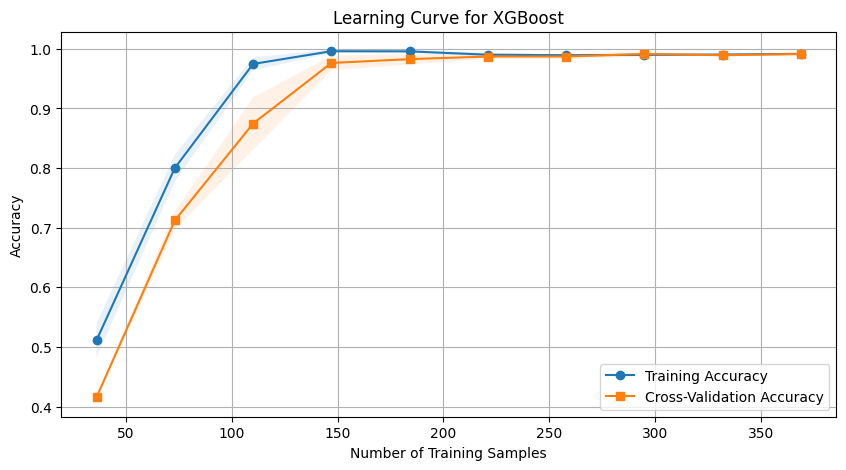

In [ ]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=randomState)

train_sizes = np.linspace(0.1, 1.0, 10)

# Compute learning curve
train_sizes, train_scores, test_scores = learning_curve(
    final_xgb,  # Model
    X_train_final, y_train,  # Data
    cv=cv, scoring='accuracy',
    train_sizes=train_sizes, n_jobs=-1, random_state=randomState
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.figure(figsize=(10, 5))
plt.plot(train_sizes, train_mean, marker='o', linestyle='-', label="Training Accuracy")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1)

plt.plot(train_sizes, test_mean, marker='s', linestyle='-', label="Cross-Validation Accuracy")
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1)

plt.xlabel("Number of Training Samples")
plt.ylabel("Accuracy")
plt.title("Learning Curve for XGBoost")
plt.legend()
plt.grid()
plt.show()


# Train and Evaluate with Simple Models with Top 70 features  

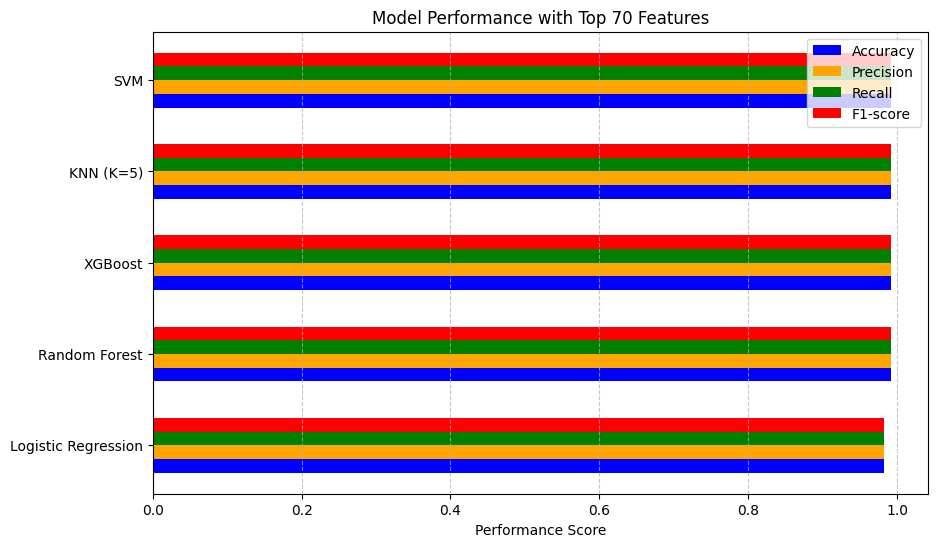

In [49]:
from sklearn.metrics import precision_score, recall_score, f1_score

top_70_features = X_train_reduced.columns[sorted_indices[:70]]
X = df_clean[top_70_features]
y = df_clean.iloc[:, -1]      

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": xgb.XGBClassifier(n_estimators=100, random_state=42),
    "KNN (K=5)": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(kernel="linear")
}

results = []

for model_name, model in models.items():
    if model_name in ["Logistic Regression", "SVM", "KNN (K=5)"]: 
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="weighted")
    recall = recall_score(y_test, y_pred, average="weighted")
    f1 = f1_score(y_test, y_pred, average="weighted")
    
    results.append((model_name, acc, precision, recall, f1))

results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1-score"])



plt.figure(figsize=(10, 6))
bar_width = 0.15 
x_pos = np.arange(len(results_df["Model"])) 

plt.barh(x_pos - 1.5 * bar_width, results_df["Accuracy"], bar_width, label="Accuracy", color="blue")
plt.barh(x_pos - 0.5 * bar_width, results_df["Precision"], bar_width, label="Precision", color="orange")
plt.barh(x_pos + 0.5 * bar_width, results_df["Recall"], bar_width, label="Recall", color="green")
plt.barh(x_pos + 1.5 * bar_width, results_df["F1-score"], bar_width, label="F1-score", color="red")

plt.yticks(x_pos, results_df["Model"]) 
plt.xlabel("Performance Score")
plt.title("Model Performance with Top 70 Features")
plt.legend()
plt.grid(axis="x", linestyle="--", alpha=0.7)

plt.show()